# CPT for Data Science Jobs on Qwen3-4B

`Qwen/Qwen3-4B-Base` is a 4B base model, which can be used for custom post-training. We use CPT on the `pymlex/datasciencejobs-tg` dataset to make the model more fluent on ML and DS job posts, vacancy patterns, and domain vocabulary for futher usage on platforms like HeadHunter or LinkedIn.

## Installation

Fine-tuning libraries installation.

In [ ]:
!pip install -U transformers accelerate peft trl huggingface-hub datasets pandas matplotlib seaborn scipy

## Imports and configuration

In [1]:
import os
import json
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import Dataset
from huggingface_hub import hf_hub_download, login
from peft import LoraConfig, PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainerCallback
from trl import SFTTrainer, SFTConfig

hf_dataset_id = "pymlex/datasciencejobs-tg"
base_model_id = "Qwen/Qwen3-4B-Base"
hub_model_id = "pymlex/qwen3-4b-ds-jobs-expert"

output_dir = "./qwen3_4b_ds_jobs_cpt"
seed = 3407

torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

bf16 = torch.cuda.is_bf16_supported()
fp16 = not bf16

device_name = torch.cuda.get_device_name(0)
device_props = torch.cuda.get_device_properties(0)
vram_gb = device_props.total_memory / (1024 ** 3)

print(f"GPU: {device_name}")
print(f"VRAM: {vram_gb:.2f} GB")


GPU: NVIDIA GeForce RTX 5090
VRAM: 31.35 GB


## Dataset download and cleanup

The dataset is loaded from Hugging Face.

In [2]:
repo_id = "pymlex/datasciencejobs-tg"
filename = "datasciencejobs.csv"

local_path = hf_hub_download(
    repo_id=repo_id,
    repo_type="dataset",
    filename=filename
)

df = pd.read_csv(local_path)
df = df.rename(columns={"viewsCount": "views"})
df["text"] = df["text"].astype(str).str.strip()
df = df.reset_index(drop=True)

print(df.shape)
df.head()


(1784, 4)


,id,date,views,text
0,4,2019-11-25 12:31:51,3932,"Коллеги, если у вас есть интересные вакансии п..."
1,6,2019-11-25 12:51:56,12046,А вот и первая вакансия:\n\n#вакансия #санкт_п...
2,7,2019-11-25 12:52:56,13729,Вакансии слать @musit в лс.\nНаш канал в Max: ...
3,9,2019-11-27 07:46:10,11398,#вакансия #python #fulltime #Москва #офис #уда...
4,10,2019-11-28 09:30:16,4570,#вакансия #devops #Москва #fultime #удаленка #...


## Train / validation / test split

A 90/5/5 hold-out split was used for training, validation, and testing. Publication dates were preserved because the dataset spans a wide period (2019–2026). Maintaining chronological order is crucial for teaching the model how the distribution of skills and market requirements has evolved over time.

In [3]:
dataset = Dataset.from_pandas(df[["text", "date"]], preserve_index=False)

split_1 = dataset.train_test_split(test_size=0.1, seed=seed)
split_2 = split_1["test"].train_test_split(test_size=0.5, seed=seed)

train_base = split_1["train"]
val_base = split_2["train"]
test_base = split_2["test"]

train_base, val_base, test_base

(Dataset({
     features: ['text', 'date'],
     num_rows: 1605
 }),
 Dataset({
     features: ['text', 'date'],
     num_rows: 89
 }),
 Dataset({
     features: ['text', 'date'],
     num_rows: 90
 }))

## Base model and LoRA

The model is loaded in bf16 without quantization. We use a RTX 5090, Ryzen 9 9950X, 64 GB RAM setup.

In [4]:
tokenizer = AutoTokenizer.from_pretrained(base_model_id, trust_remote_code=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    device_map="auto",
    torch_dtype=torch.bfloat16 if bf16 else torch.float16,
    trust_remote_code=True,
)

model.config.use_cache = False

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

## Datasets and dataloader

The raw post text is used as plain language modeling data. EOS is appended to every sample.

In [5]:
def format_example(example):
    text = f"Date: {example['date']}\n{example['text']}" + tokenizer.eos_token
    n_tokens = len(tokenizer(text, add_special_tokens=False)["input_ids"])
    return {"text": text, "n_tokens": n_tokens}

train_ds = train_base.map(format_example, remove_columns=train_base.column_names)
val_ds = val_base.map(format_example, remove_columns=val_base.column_names)
test_ds = test_base.map(format_example, remove_columns=test_base.column_names)

Map:   0%|          | 0/1605 [00:00<?, ? examples/s]

Map:   0%|          | 0/89 [00:00<?, ? examples/s]

Map:   0%|          | 0/90 [00:00<?, ? examples/s]

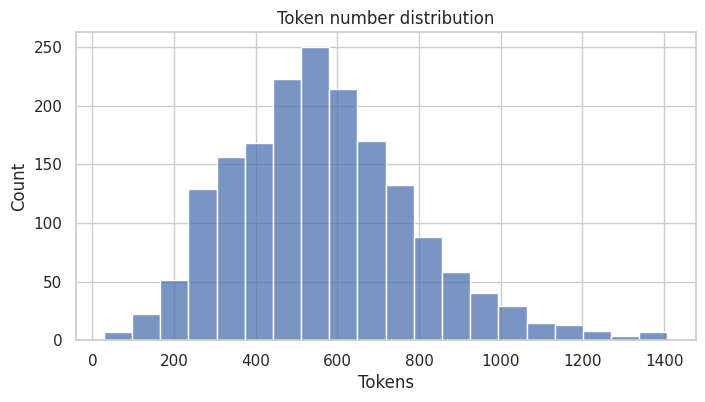

In [6]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 4))

all_tokens = []

for ds in [train_ds, val_ds, test_ds]:
    all_tokens.extend(ds["n_tokens"])

sns.histplot(all_tokens, bins=20)

plt.title("Token number distribution")
plt.xlabel("Tokens")
plt.ylabel("Count")
plt.show()

We set `max_seq_length` to 1024 to improve performance with minimal data loss. `text` shorter than 50 tokens is removed after loading because it is usually not a job description, but HR contacts related to a previous post or just channel info.

In [7]:
max_seq_length = 1024

In [8]:
train_ds = train_ds.filter(lambda x: 50 <= x["n_tokens"] <= max_seq_length)
val_ds = val_ds.filter(lambda x: 50 <= x["n_tokens"] <= max_seq_length)
test_ds = test_ds.filter(lambda x: 50 <= x["n_tokens"] <= max_seq_length)

train_ds = train_ds.remove_columns(["n_tokens"])
val_ds = val_ds.remove_columns(["n_tokens"])
test_ds = test_ds.remove_columns(["n_tokens"])

train_ds, val_ds, test_ds

Filter:   0%|          | 0/1605 [00:00<?, ? examples/s]

Filter:   0%|          | 0/89 [00:00<?, ? examples/s]

Filter:   0%|          | 0/90 [00:00<?, ? examples/s]

(Dataset({
     features: ['text'],
     num_rows: 1546
 }),
 Dataset({
     features: ['text'],
     num_rows: 85
 }),
 Dataset({
     features: ['text'],
     num_rows: 86
 }))

In [9]:
train_ds[0]

{'text': 'Date: 2024-05-22 18:32:13\n#hiring #вакансия #удаленка #datascentist\n\nДолжность: Senior data scientist\nФормат работы: удаленный (из любой точки мира)/гибрид Москва/Самара\nЗанятость: #полная, #fulltime \nЗарплатная вилка: до 500 000 руб. на руки \n\nPravo Tech — основоположники Legal Tech в России.\n\nМы ускорили работу юристов в Тинькофф Страхование на 50%, сэкономили 30% времени юрдепу в Ростелекоме, провели крупнейший в Европе форум по автоматизации юридических процессов и не собираемся останавливаться!\n\nМы создаем решения для автоматизации процессов в бизнесе, которые избавляют людей от рутины и дают возможность заниматься творческими задачами. С нами вы всегда будете видеть результат работы.\n\nОсновные задачи:\nАнализ бизнес-требований к функциям ML и формирование требований к моделям ML и алгоритмам.\nСбор, подготовка и управление данными.\nРазработка моделей ML и алгоритмов.\nАвтоматизация процессов ML.\nПроектирование архитектуры компонентов ML в продукте.\nРазр

## Training setup

We log loss and GPU load during training.

In [13]:
gpu_history = []

class TrainStatusCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs:
            return

        if not torch.cuda.is_available():
            return

        device_id = torch.cuda.current_device()
        raw = subprocess.check_output([
            "nvidia-smi",
            "--query-gpu=utilization.gpu,memory.used,memory.total",
            "--format=csv,noheader,nounits",
        ]).decode("utf-8").strip().splitlines()[device_id]

        gpu_util, mem_used, mem_total = [x.strip() for x in raw.split(",")]

        loss = logs.get("loss", None)
        eval_loss = logs.get("eval_loss", None)

        msg = f"[STEP {state.global_step}] "

        if loss is not None:
            msg += f"loss={loss:.4f} | "

        if eval_loss is not None:
            msg += f"eval_loss={eval_loss:.4f} | "

        msg += f"GPU={gpu_util}% | VRAM={mem_used}/{mem_total} MB"
        print(msg)

        row = {
            "step": state.global_step,
            "gpu_util": float(gpu_util),
            "mem_used": float(mem_used),
            "mem_total": float(mem_total),
            "loss": logs.get("loss", np.nan),
            "eval_loss": logs.get("eval_loss", np.nan),
        }
        gpu_history.append(row)

training_args = SFTConfig(
    output_dir=output_dir,
    per_device_train_batch_size=6,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    learning_rate=1e-4,
    warmup_steps=50,
    lr_scheduler_type="cosine",
    optim="adamw_torch",

    logging_strategy="steps",
    logging_steps=1,

    eval_strategy="steps",
    eval_steps=10,
    eval_on_start=True,

    save_strategy="steps",
    save_steps=50,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    bf16=bf16,
    fp16=fp16,
    report_to="none",
    seed=seed,
    packing=False,
    dataset_text_field="text",
    max_length=max_seq_length,
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    peft_config=lora_config,
)

trainer.add_callback(TrainStatusCallback())

Adding EOS to train dataset:   0%|          | 0/1546 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/1546 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/85 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/85 [00:00<?, ? examples/s]

## Training and saving

In [14]:
train_result = trainer.train()
train_result

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss
0,No log,1.940935
10,1.891666,1.935828
20,1.918559,1.889401
30,1.860266,1.825014
40,1.839923,1.791550
50,1.667753,1.762879
60,1.663154,1.738372
70,1.731239,1.723346
80,1.688717,1.709450
90,1.724273,1.699367


[STEP 0] eval_loss=1.9409 | GPU=93% | VRAM=21724/32607 MB
[STEP 1] loss=1.9765 | GPU=18% | VRAM=31882/32607 MB
[STEP 2] loss=1.8798 | GPU=99% | VRAM=25760/32607 MB
[STEP 3] loss=1.9573 | GPU=93% | VRAM=25760/32607 MB
[STEP 4] loss=1.9466 | GPU=99% | VRAM=25760/32607 MB
[STEP 5] loss=1.9817 | GPU=99% | VRAM=25768/32607 MB
[STEP 6] loss=1.8783 | GPU=98% | VRAM=25768/32607 MB
[STEP 7] loss=1.8600 | GPU=98% | VRAM=25768/32607 MB
[STEP 8] loss=1.8489 | GPU=99% | VRAM=25768/32607 MB
[STEP 9] loss=1.8877 | GPU=99% | VRAM=25768/32607 MB
[STEP 10] loss=1.8917 | GPU=93% | VRAM=25768/32607 MB
[STEP 10] eval_loss=1.9358 | GPU=96% | VRAM=25768/32607 MB
[STEP 11] loss=1.8778 | GPU=99% | VRAM=25768/32607 MB
[STEP 12] loss=1.9342 | GPU=99% | VRAM=25768/32607 MB
[STEP 13] loss=1.8850 | GPU=99% | VRAM=25768/32607 MB
[STEP 14] loss=1.9009 | GPU=85% | VRAM=29636/32607 MB
[STEP 15] loss=1.8813 | GPU=99% | VRAM=29636/32607 MB
[STEP 16] loss=1.9904 | GPU=99% | VRAM=29636/32607 MB
[STEP 17] loss=1.8805 | GPU=

TrainOutput(global_step=195, training_loss=1.684807657584166, metrics={'train_runtime': 1083.9236, 'train_samples_per_second': 4.279, 'train_steps_per_second': 0.18, 'total_flos': 8.133779219579904e+16, 'train_loss': 1.684807657584166})

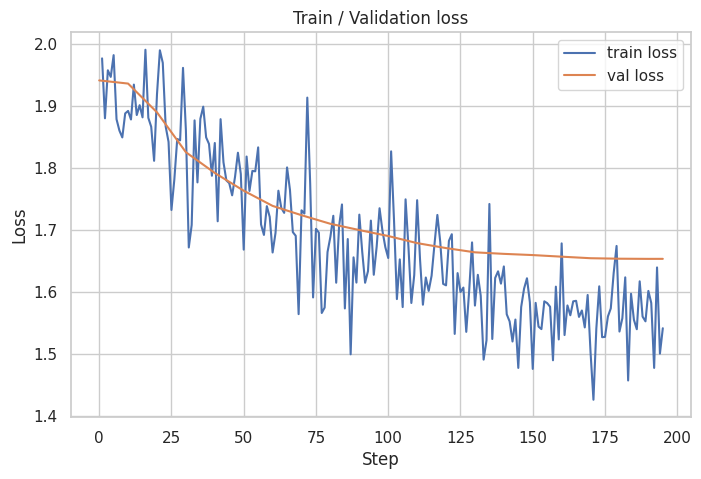

In [16]:
train_logs = logs[["step", "loss"]].dropna()
eval_logs = logs[["step", "eval_loss"]].dropna()

plt.figure(figsize=(8, 5))

plt.plot(train_logs["step"], train_logs["loss"], label="train loss")
plt.plot(eval_logs["step"], eval_logs["eval_loss"], label="val loss")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Train / Validation loss")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)

('./qwen3_4b_ds_jobs_cpt/tokenizer_config.json',
 './qwen3_4b_ds_jobs_cpt/chat_template.jinja',
 './qwen3_4b_ds_jobs_cpt/tokenizer.json')

## Push to HF

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from huggingface_hub import login
import torch

base_model_id = "Qwen/Qwen3-4B-Base"

tokenizer = AutoTokenizer.from_pretrained(output_dir)

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    device_map="auto",
    torch_dtype=torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16,
)

model = PeftModel.from_pretrained(base_model, output_dir)
model.eval()

In [21]:
login(token="YOUR_TOKEN")
model.push_to_hub(hub_model_id)
tokenizer.push_to_hub(hub_model_id)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/pymlex/qwen3-4b-ds-jobs-expert/commit/093bcc06e08fe6448de6304c187cf66309245e0f', commit_message='Upload tokenizer', commit_description='', oid='093bcc06e08fe6448de6304c187cf66309245e0f', pr_url=None, repo_url=RepoUrl('https://huggingface.co/pymlex/qwen3-4b-ds-jobs-expert', endpoint='https://huggingface.co', repo_type='model', repo_id='pymlex/qwen3-4b-ds-jobs-expert'), pr_revision=None, pr_num=None)

## Inference

These are the daily use cells.

In [23]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

base_model_id = "Qwen/Qwen3-4B-Base"
adapter_id = hub_model_id

tokenizer = AutoTokenizer.from_pretrained(base_model_id, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    device_map="auto",
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16,
    trust_remote_code=True,
)

model = PeftModel.from_pretrained(base_model, adapter_id)
model.eval()

def generate_continuation(model, tokenizer, prompt, max_new_tokens=260):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    prompt_len = inputs.input_ids.shape[1]

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        temperature=0.7,
        top_p=0.9,
        do_sample=True,
        repetition_penalty=1.08,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id,
    )

    decoded = tokenizer.decode(outputs[0][prompt_len:], skip_special_tokens=True)
    return decoded.strip()

sample_prompt = (
    "#вакансия #ml #python #удаленно\n"
    "Ищем Machine Learning Engineer в продуктовую команду. "
    "Задачи: построение и запуск моделей, работа с данными, эксперименты, "
    "поддержка ML-пайплайнов, участие в развитии продукта. "
)

output = generate_continuation(model, tokenizer, sample_prompt, max_new_tokens=1000)
print("Prompt:")
print(sample_prompt)
print("\nGenerated continuation:")
print(output)


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


Prompt:
#вакансия #ml #python #удаленно
Ищем Machine Learning Engineer в продуктовую команду. Задачи: построение и запуск моделей, работа с данными, эксперименты, поддержка ML-пайплайнов, участие в развитии продукта. 

Generated continuation:
100% удаленная работа.

Условия:
- Полная удаленка;
- Удаленный митап или корпоративный офис в Москве/Санкт-Петербурге;
- График работы гибкий (8ч);
- Зарплатная вилка от 250.000 до 360.000 рублей на руки;
- Стабильное оформление: ТК РФ + ДМС со стоматологией;

Обязанности:
- Построение моделей машинного обучения для анализа данных, прогнозирования и классификации.
- Обработка и анализ больших объемов данных, подготовка датасетов, проведение EDA.
- Реализация и оптимизация алгоритмов машинного обучения.
- Разработка и поддержка ML-пайплайнов.
- Взаимодействие с командой разработки и другими отделами для интеграции ML-решений в продукты компании.

Требования к опыту:
- Опыт работы в области machine learning от 2 лет;
- Глубокое знание Python и библ

## Perplexity evaluation on test

We use the whole test set.

In [10]:
def compute_perplexity(model, tokenizer, dataset, max_length=3072):
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    with torch.inference_mode():
        for example in dataset:
            text = example["text"] + tokenizer.eos_token
            encodings = tokenizer(
                text,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            ).to(model.device)

            outputs = model(**encodings, labels=encodings["input_ids"])
            loss = outputs.loss
            n_tokens = encodings["input_ids"].numel()

            total_loss += loss.item() * n_tokens
            total_tokens += n_tokens

    avg_loss = total_loss / total_tokens
    perplexity = np.exp(avg_loss)
    return perplexity, avg_loss

base_model_id = "Qwen/Qwen3-4B-Base"
tokenizer = AutoTokenizer.from_pretrained(base_model_id, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    device_map="auto",
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16,
    trust_remote_code=True,
)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Fine-tuning resulted in a significant performance boost, reducing Perplexity by 23% and Loss by 13%. The lower perplexity indicates that the tuned model is substantially more confident and accurate in predicting tokens within the specific domain of ML job descriptions compared to the base model.

In [11]:
ppl_base, loss_base = compute_perplexity(base_model, tokenizer, test_ds)
print(f"Base model: Perplexity = {ppl_base:.3f}, Loss = {loss_base:.4f}")

adapter_id = hub_model_id
model = PeftModel.from_pretrained(base_model, adapter_id)
ppl_tuned, loss_tuned = compute_perplexity(model, tokenizer, test_ds)
print(f"Tuned model: Perplexity = {ppl_tuned:.3f}, Loss = {loss_tuned:.4f}")

pd.DataFrame([
    {"model": "base", "perplexity": ppl_base, "loss": loss_base},
    {"model": "tuned", "perplexity": ppl_tuned, "loss": loss_tuned},
])

Base model: Perplexity = 7.014, Loss = 1.9479
Tuned model: Perplexity = 5.409, Loss = 1.6881


,model,perplexity,loss
0,base,7.014077,1.947919
1,tuned,5.409219,1.688105
